In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("carprices.csv")

In [3]:
df

,Car Model,Mileage,Sell Price($),Age(yrs)
0,BMW X5,69000,18000,6
1,BMW X5,35000,34000,3
2,BMW X5,57000,26100,5
3,BMW X5,22500,40000,2
4,BMW X5,46000,31500,4
5,Audi A5,59000,29400,5
6,Audi A5,52000,32000,5
7,Audi A5,72000,19300,6
8,Audi A5,91000,12000,8
9,Mercedez Benz C class,67000,22000,6


In [5]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

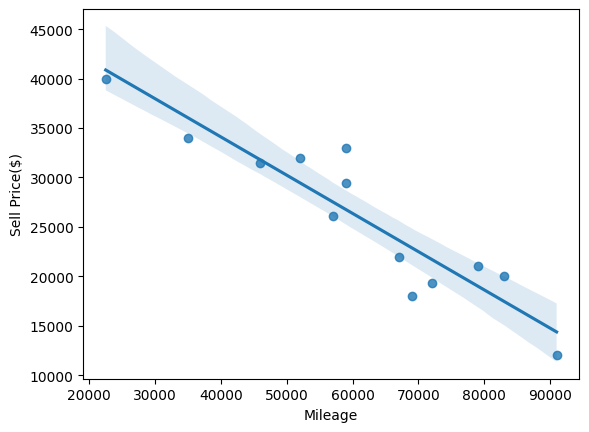

In [7]:
sns.regplot(data= df , x = 'Mileage' , y = 'Sell Price($)')
plt.show()

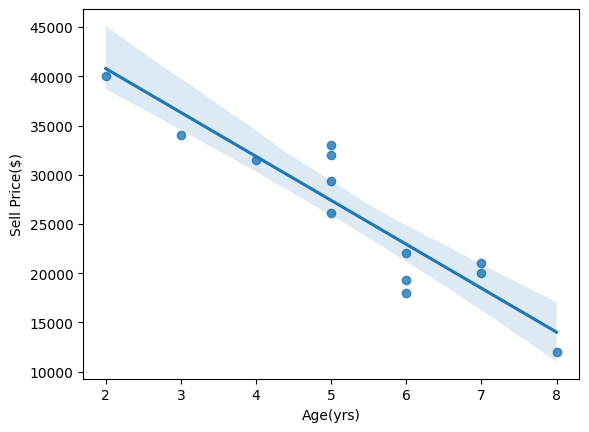

In [8]:
sns.regplot(data= df , x = 'Age(yrs)' , y = 'Sell Price($)')
plt.show()

In [9]:
le = LabelEncoder()

In [10]:
df['Car Model'] = le.fit_transform(df['Car Model'])

In [11]:
df['Car Model'] 

0     1
1     1
2     1
3     1
4     1
5     0
6     0
7     0
8     0
9     2
10    2
11    2
12    2
Name: Car Model, dtype: int32

In [12]:
x = df[['Car Model','Mileage','Age(yrs)']]

In [14]:
y = df['Sell Price($)']

In [15]:
ohe = OneHotEncoder()
x1 = ohe.fit_transform(df[['Car Model'] ])

In [16]:
x1 = pd.DataFrame(x1.toarray())

In [18]:
x1.astype('int')

,0,1,2
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0
5,1,0,0
6,1,0,0
7,1,0,0
8,1,0,0
9,0,0,1


In [20]:
x1 = x1.iloc[ : , 1:]
x1 # avoid dummy varibale trap , drop 0th columns

,1,2
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0
5,0.0,0.0
6,0.0,0.0
7,0.0,0.0
8,0.0,0.0
9,0.0,1.0


In [21]:
X = pd.concat([x , x1], axis = 'columns')

In [22]:
X

,Car Model,Mileage,Age(yrs),1,2
0,1,69000,6,1.0,0.0
1,1,35000,3,1.0,0.0
2,1,57000,5,1.0,0.0
3,1,22500,2,1.0,0.0
4,1,46000,4,1.0,0.0
5,0,59000,5,0.0,0.0
6,0,52000,5,0.0,0.0
7,0,72000,6,0.0,0.0
8,0,91000,8,0.0,0.0
9,2,67000,6,0.0,1.0


In [23]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [25]:
reg.fit(X , y)

TypeError: Feature names are only supported if all input features have string names, but your input has ['int', 'str'] as feature name / column name types. If you want feature names to be stored and validated, you must convert them all to strings, by using X.columns = X.columns.astype(str) for example. Otherwise you can remove feature / column names from your input data, or convert them all to a non-string data type.